In [1]:
import mujoco
import mediapy as media
import numpy as np

In [2]:
xml= 'xml_models/world.xml'
model = mujoco.MjModel.from_xml_path(xml)

In [3]:
#tells what geometries are in the model
try:
  model.geom()
except KeyError as e:
  print(e)

"Invalid name ''. Valid names: ['1base_geom', '1base_plate_geom', '1bottom_l', '1bottom_r', '1camera_stand_geom', '1table_top_geom', '1top_l', '1top_r', 'apriltag_36h11_0', 'block_2block', 'block_block', 'deformed_slice_2slice', 'deformed_slice_slice', 'full_slice_2slice', 'full_slice_slice', 'ground_plane', 'plate_collision_geom', 'plate_visual_geom', 'rod_2rod', 'rod_rod']"


In [4]:
#tells us properties of the geometries in the model
model.geom('apriltag_36h11_0')
#you can add . + attribute to see the properties of the geometry, for example model.geom('apriltag_36h11_0').size will give you the size of the geometry

<_MjModelGeomViews
  bodyid: array([9], dtype=int32)
  conaffinity: array([0], dtype=int32)
  condim: array([3], dtype=int32)
  contype: array([0], dtype=int32)
  dataid: array([-1], dtype=int32)
  friction: array([1.e+00, 5.e-03, 1.e-04])
  gap: array([0.])
  group: array([0], dtype=int32)
  id: 9
  margin: array([0.])
  matid: array([0], dtype=int32)
  name: 'apriltag_36h11_0'
  pos: array([0., 0., 0.])
  priority: array([0], dtype=int32)
  quat: array([1., 0., 0., 0.])
  rbound: array([0.])
  rgba: array([0.5, 0.5, 0.5, 1. ], dtype=float32)
  sameframe: array([1], dtype=uint8)
  size: array([0.03 , 0.03 , 0.001])
  solimp: array([9.0e-01, 9.5e-01, 1.0e-03, 5.0e-01, 2.0e+00])
  solmix: array([1.])
  solref: array([0.02, 1.  ])
  type: array([0], dtype=int32)
  user: array([], dtype=float64)
>

In [5]:
[model.geom(i).name for i in range(model.ngeom)]

['ground_plane',
 '1bottom_l',
 '1top_l',
 '1bottom_r',
 '1top_r',
 '1table_top_geom',
 '1base_geom',
 '1base_plate_geom',
 '1camera_stand_geom',
 'apriltag_36h11_0',
 'plate_visual_geom',
 'plate_collision_geom',
 'full_slice_slice',
 'deformed_slice_slice',
 'rod_rod',
 'block_block',
 'full_slice_2slice',
 'deformed_slice_2slice',
 'rod_2rod',
 'block_2block']

In [6]:
#contains everything about the enviornment
data = mujoco.MjData(model)
#example gives us all the x_pos 
print(data.geom_xpos)

#CURRENTLY ZERO SINCE WE NEED TO DO SOME SORT OF mujoco.mj_forward TO UPDATE THE DATA
# we use kinematics since we don't need velocities etc
mujoco.mj_kinematics(model, data)

print(data.geom_xpos)


[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-3.75000000e-01 -2.25000000e-01  5.10000000e-02]
 [-3.75000000e-01  2.25000000e-01  5.10000000e-02]
 [ 3.75000000e-01 -2.25000000e-01  5.10000000e-02]
 [ 3.75000000e-01  2.25000000e-01  5.10000000e-02]
 [ 0.00000000e+00  0.00000000e+00  1.11000000e-01]
 [-7.85497744e-03 -4.61584977e-18  1.45941976e-01]
 [-1.06453736e-09  1.06644552e-18  1.45000000e-01]
 [ 1.17146799e-01  1.00678536e-07  3.85926556e-01]
 [-1.65000000e-01 -1.00000000e-01  1.65500000e-01]
 [-7.54983882e-19  2.06203157e-18  1.60229955e-01]
 [ 1.84963079e-19 -5.54356258e-19  1.59549000e-01]
 [-1.20000000e-01 -7.00000000e-02  1.80000000e-01]
 [ 2.00000000e-02 -7.00000000e-02  1.80000000e-01]
 [-1.00000000e-01  7.00000000e-02  1.80000000

Rendering

""

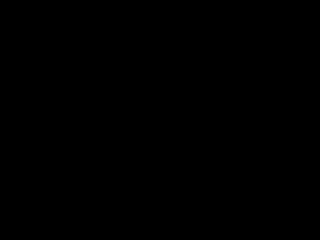

""

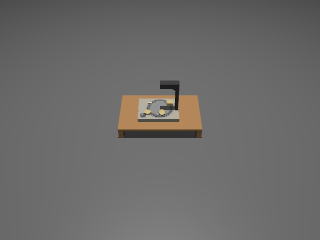

In [7]:
# Make renderer, render and show the pixels
with mujoco.Renderer(model) as renderer:
  media.show_image(renderer.render())

#black again ince we need to forward the data
with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())



SHORT HAND NOT RECOMENDED WAY TO UPDATE DATA, KEY FOR DOMAIN RANDOMIZATION


""

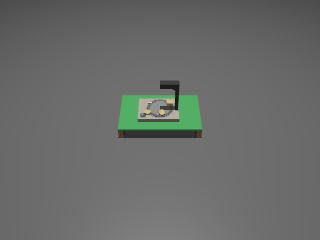

In [8]:
#remeber model.geom just returns the data of the object
model.geom('1table_top_geom').rgba[:3] = np.random.rand(3)
with mujoco.Renderer(model) as renderer:
  renderer.update_scene(data)

  media.show_image(renderer.render())

VIDEO

In [9]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

USE JOINTS TO ADD DOFs BETWEEN OBJECTS, EXAMPLE NOT NEEDED

In [10]:
#physics options
#deterimines how much time to simulate between time-steps, smaller timestep means more accurate simulation but slower
model.opt.timestep

0.002

In [11]:
#Example controlling phsyics options
#model.opt.gravity = (0, 0, -9.81)
print(model.opt)



<MjOption
  ccd_iterations: 35
  ccd_tolerance: 1e-06
  cone: 0
  density: 0.0
  disableactuator: 0
  disableflags: 0
  enableflags: 0
  gravity: array([ 0.     ,  0.     , -9.80665])
  impratio: 1.0
  integrator: 0
  iterations: 100
  jacobian: 2
  ls_iterations: 50
  ls_tolerance: 0.01
  magnetic: array([ 0. , -0.5,  0. ])
  noslip_iterations: 0
  noslip_tolerance: 1e-06
  o_friction: array([1.e+00, 1.e+00, 5.e-03, 1.e-04, 1.e-04])
  o_margin: 0.0
  o_solimp: array([9.0e-01, 9.5e-01, 1.0e-03, 5.0e-01, 2.0e+00])
  o_solref: array([0.02, 1.  ])
  sdf_initpoints: 40
  sdf_iterations: 10
  sleep_tolerance: 0.0001
  solver: 2
  timestep: 0.002
  tolerance: 1e-08
  viscosity: 0.0
  wind: array([0., 0., 0.])
>
